# Two-Tower Movie Retrieval on MovieLens 100K

**Candidate retrieval** system that takes a `user_id` and returns Top-K movie candidates,
built with temporal evaluation discipline and an exportable serving index.

| | |
|---|---|
| **Task** | Personalized candidate retrieval (retrieval stage, *not* ranking) |
| **Dataset** | GroupLens MovieLens 100K — 100,000 ratings, 943 users, 1,682 movies |
| **Split** | Temporal leave-last-1-out per user (last interaction → test, second-last → val) |
| **Baseline** | Global popularity Top-K (train statistics only) |
| **Model** | Two-tower user/movie embeddings, in-batch sampled softmax (pure TensorFlow/Keras) |
| **Metrics** | Recall@10/50, NDCG@10/50, catalogue coverage, popularity bias, activity/popularity slices |
| **Serving** | Brute-force Top-K SavedModel index + unknown-user popularity fallback |

**Success criteria**
1. Per-user temporal split with no future leakage (audited by assertions).
2. Popularity baseline with metrics matching the Top-K retrieval task.
3. Two-tower model evaluated on the full catalogue (no candidate sampling bias).
4. Coverage, popularity-bias, and user/item slice reporting.
5. Exportable, reload-consistent serving index with a cold-start fallback policy.

> All reusable logic lives in the `movie_retrieval` package (`src/`) with unit tests.
> This notebook is the *narrative*: every section explains **why** before **what**.

## 01 — Project overview

**Business problem.** Platforms with large catalogues cannot afford to score every item
with an expensive ranking model on every request. Production recommenders therefore use a
**retrieval stage** that narrows the catalogue to a few hundred candidates, followed by a
**ranking stage** that orders them with richer features.

This project simulates the retrieval layer:

```
Ratings/events → Temporal split → User tower ┐
                                             ├→ dot-product similarity → Top-K index → business filters
                              Movie tower ───┘
```

**Decision supported:** which candidates to show (or forward to ranking) for a user at request time.

**Why offline evaluation must mirror serving.** The system predicts *future* behaviour from
*past* behaviour, so the offline protocol splits per-user by time. A random split would let
the model peek at the future and inflate every metric.

**Scope (10-hour MVP)**
- ✅ ID-only two-tower retrieval + popularity baseline + temporal evaluation + brute-force index
- ❌ Ranking stage, real-time context features, online A/B testing, ANN infrastructure

**Interaction signal caveat.** MovieLens has explicit 1–5 ratings but *no impressions*.
We convert ratings to implicit positives under a declared rule (default: every rating is an
interaction; Section 14 tests `rating >= 4` as an alternative). Non-interaction ≠ dislike —
the user may simply never have seen the item.

## 02 — Environment & reproducibility

Pinned dependencies live in `requirements-lock.txt`. Seeds are fixed for shuffling and
initialization; the temporal split itself is fully deterministic (timestamp + movie_id
tie-break), so re-running this notebook reproduces the same splits and the same metrics.

The first cell bootstraps the package: on a bare runtime (Colab) it clones the repository
and installs it, and on a machine that already has `movie_retrieval` it does nothing.
**Runtime → Restart → Run all works from an empty Colab runtime with no manual edits.**
Outside a checkout there is no `pyproject.toml` above the working directory, so
`Paths.default()` resolves the project root to the current directory (`/content` on Colab)
and writes `data/` and `artifacts/` there — the `project root` line printed below is what
tells you which layout you are in.


In [1]:
# ── Colab bootstrap ── install the package from GitHub if missing (no-op when local)
import importlib.util
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/Sayomphon/Two_Tower_Movie_Retrieval.git"

if importlib.util.find_spec("movie_retrieval") is None:
    repo = Path("Two_Tower_Movie_Retrieval").resolve()
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "-q", REPO_URL, str(repo)], check=True)
    # a normal install, not -e: an editable install writes a .pth that Python reads only
    # at interpreter start → this process would not see it and Run all breaks next cell
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", f"{repo}[dev]"], check=True)
    importlib.invalidate_caches()  # let import see the new package without a restart
    print(f"bootstrapped movie_retrieval from {repo}")
else:
    print("movie_retrieval already importable — bootstrap skipped")


movie_retrieval already importable — bootstrap skipped


In [2]:
import json
import platform
import sys

import numpy as np
import pandas as pd
import tensorflow as tf

from movie_retrieval import __version__
from movie_retrieval.config import ExperimentConfig, ModelConfig, Paths

SEED = 42
tf.keras.utils.set_random_seed(SEED)

paths = Paths.default()
cfg = ExperimentConfig()

print(f"python          {platform.python_version()}")
print(f"tensorflow      {tf.__version__}")
print(f"numpy           {np.__version__}")
print(f"pandas          {pd.__version__}")
print(f"movie_retrieval {__version__}")
print(f"project root    {paths.root}")

python          3.11.15
tensorflow      2.20.0
numpy           2.4.6
pandas          2.3.3
movie_retrieval 0.1.0
project root    /Users/sayomphon.kha/Documents/AI_Projects/Movie_Recommender


## 03 — Data ingestion

The raw dataset is **downloaded at runtime over HTTPS and verified against a pinned SHA-256**
before use — it is never committed to the repository, because GroupLens licenses MovieLens
for research use and does not permit redistribution or commercial use.

In [3]:
from movie_retrieval.data import load_ratings, load_movie_titles

ratings = load_ratings(paths.raw_dir)
titles = load_movie_titles(paths.raw_dir)

print(ratings.shape)
ratings.head()

(100000, 4)


,user_id,movie_id,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


## 04 — Data contract

Before any modelling, the data must pass an explicit contract. A violation raises and stops
the pipeline — silently training on malformed data is how leakage and garbage metrics happen.

Checks: schema/dtypes (IDs are *strings*, not numbers), rating range 1–5, positive timestamps,
no nulls, no duplicate `(user, movie)` pairs, and the known ML-100K statistics
(100,000 ratings / 943 users / ≤1,682 movies).

In [4]:
from movie_retrieval.data import validate_ratings

data_card = validate_ratings(ratings)
data_card

DataCard(source_url='https://files.grouplens.org/datasets/movielens/ml-100k.zip', sha256='50d2a982c66986937beb9ffb3aa76efe955bf3d5c6b761f4e3a7cd717c6a3229', n_ratings=100000, n_users=943, n_movies=1682)

## 05 — EDA: activity, popularity long tail, timestamps

Three questions matter for retrieval design:
1. **User activity** — is there enough history per user for leave-last-k-out? (ML-100K guarantees ≥ 20.)
2. **Item popularity** — how heavy is the long tail? This calibrates how strong a popularity
   baseline will be and why coverage must be a guardrail metric.
3. **Timestamps** — do interactions span enough time for a temporal split to be meaningful?

In [5]:
user_activity = ratings.groupby("user_id").size()
item_popularity = ratings.groupby("movie_id").size().sort_values(ascending=False)
ts = pd.to_datetime(ratings["timestamp"], unit="s")

print(f"interactions per user: min={user_activity.min()}, median={user_activity.median():.0f}, max={user_activity.max()}")
print(f"interactions per movie: median={item_popularity.median():.0f}, max={item_popularity.max()}")
print(f"top-10% most popular movies cover {item_popularity.head(len(item_popularity)//10).sum() / len(ratings):.1%} of all interactions")
print(f"time span: {ts.min():%Y-%m-%d} → {ts.max():%Y-%m-%d}")

interactions per user: min=20, median=65, max=737
interactions per movie: median=27, max=583
top-10% most popular movies cover 42.7% of all interactions
time span: 1997-09-20 → 1998-04-22


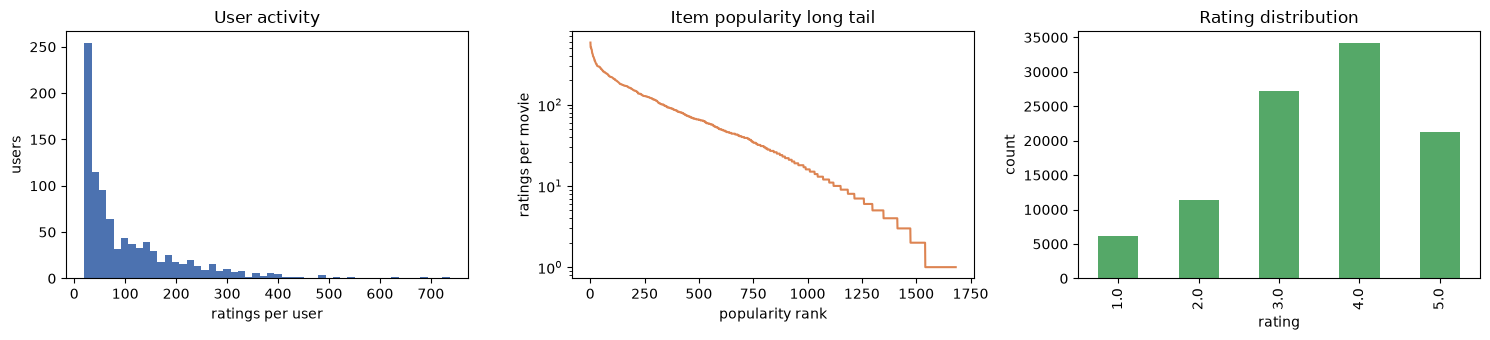

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].hist(user_activity, bins=50, color="#4c72b0")
axes[0].set(title="User activity", xlabel="ratings per user", ylabel="users")

axes[1].plot(range(1, len(item_popularity) + 1), item_popularity.values, color="#dd8452")
axes[1].set(title="Item popularity long tail", xlabel="popularity rank", ylabel="ratings per movie", yscale="log")

ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="#55a868")
axes[2].set(title="Rating distribution", xlabel="rating", ylabel="count")

fig.tight_layout()
plt.show()

## 06 — Leakage analysis

**Why not a random split?** With a random interaction split, a user's *later* interactions
can land in train while *earlier* ones land in test — the model learns from the future to
predict the past. Popularity statistics computed on the full dataset leak future trends the
same way.

**Controls used here**
1. Per-user temporal ordering: train < val < test by timestamp (ties broken by `movie_id`
   so the split is deterministic).
2. Vocabulary and popularity counts are built **from train only**. Items first appearing in
   val/test are out-of-vocabulary (OOV) — reported, not silently dropped.
3. An automated audit (`audit_no_leakage`) asserts the three invariants below on every split.
   It raises `LeakageError` — the experiment cannot proceed with a broken split.

## 07 — Split strategy: temporal leave-last-1-out per user

Per user (sorted by timestamp): last interaction → **test**, second-last → **val**,
everything before → **train**. Users with fewer than `k_test + k_val + min_train = 5`
interactions would be dropped by policy (none are, in ML-100K).

In [7]:
from movie_retrieval.splits import audit_no_leakage, temporal_leave_last_k

split = temporal_leave_last_k(ratings, cfg.split)   # audit runs inside; raises on any leakage
audit_report = audit_no_leakage(split, cfg.split)
pd.Series(audit_report)

temporal_ordering_ok      True
min_train_history_ok      True
no_test_train_overlap     True
n_train                  98114
n_val                      943
n_test                     943
n_train_users              943
n_test_users               943
n_users_dropped              0
dtype: object

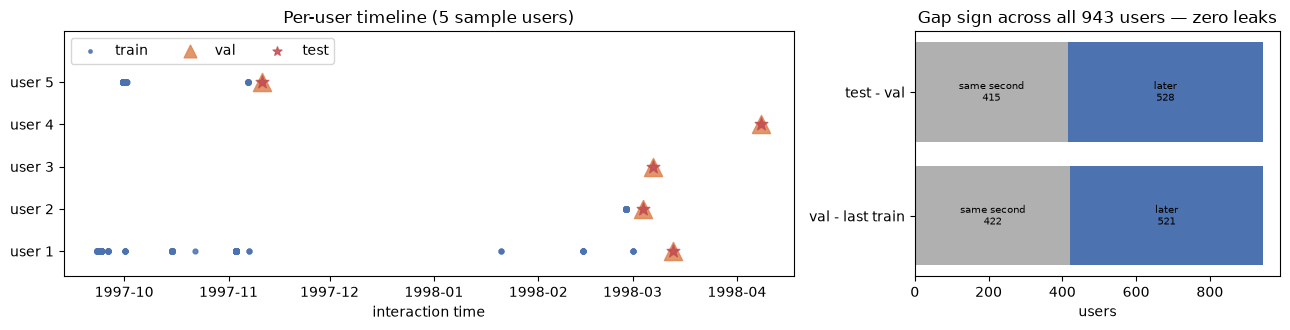

In [8]:
# Visual proof of the split rule: per-user timelines, then the same invariant across every user
sample_users = sorted(split.test["user_id"].unique(), key=int)[:5]
row_of = {user_id: row for row, user_id in enumerate(sample_users)}

fig, (timeline, gap_ax) = plt.subplots(1, 2, figsize=(13, 3.4), width_ratios=[2, 1])

# val is drawn largest and test smallest on purpose: the two often share a second, and the
# marker peeking out from under the star is what that tie looks like
for frame, label, color, marker, size, layer in [
    (split.train, "train", "#4c72b0", "o", 12, 1),
    (split.val, "val", "#dd8452", "^", 170, 2),
    (split.test, "test", "#c44e52", "*", 90, 3),
]:
    subset = frame[frame["user_id"].isin(sample_users)]
    timeline.scatter(pd.to_datetime(subset["timestamp"], unit="s"), subset["user_id"].map(row_of),
                     s=size, marker=marker, color=color, alpha=0.85, zorder=layer, label=label)

timeline.set(yticks=range(len(sample_users)), yticklabels=[f"user {u}" for u in sample_users],
             ylim=(-0.6, len(sample_users) + 0.2),
             xlabel="interaction time", title="Per-user timeline (5 sample users)")
timeline.legend(loc="upper left", ncols=3, markerscale=0.7)

# The audit's invariant, counted over the whole population: no evaluation point may look back
last_train = split.train.groupby("user_id")["timestamp"].max()
val_ts = split.val.set_index("user_id")["timestamp"]
test_ts = split.test.set_index("user_id")["timestamp"]
gaps = pd.DataFrame({"val - last train": val_ts - last_train.reindex(val_ts.index),
                     "test - val": test_ts - val_ts.reindex(test_ts.index)})
counts = gaps.apply(lambda gap: pd.Series({"earlier (leak)": (gap < 0).sum(),
                                           "same second": (gap == 0).sum(),
                                           "later": (gap > 0).sum()}))

left = np.zeros(len(counts.columns))
for bucket, color in [("earlier (leak)", "#c44e52"), ("same second", "#b0b0b0"),
                      ("later", "#4c72b0")]:
    widths = counts.loc[bucket].to_numpy()
    gap_ax.barh(counts.columns, widths, left=left, color=color)
    for row, (width, start) in enumerate(zip(widths, left, strict=True)):
        if width:                                   # empty buckets label nothing — 0 leaks stays blank
            gap_ax.text(start + width / 2, row, f"{bucket}\n{width}",
                        ha="center", va="center", fontsize=7)
    left += widths

gap_ax.set(xlabel="users", title=f"Gap sign across all {len(val_ts)} users — zero leaks")

fig.tight_layout()
plt.show()

Each row on the left is one user's timeline: the orange (val) and red (test) markers sit at
the right edge of the blue training history, where a random split would scatter them
throughout the row.

The right panel is the honest version of that claim, counted over **every** user rather than
five: the leak bucket is empty, but a large share of users rated several movies within the
*same second*, so `val - last train` is exactly zero for them. Those ties are broken
deterministically by `movie_id` inside `temporal_leave_last_k`, which is why the audit
asserts `train ≤ val ≤ test` rather than a strict inequality — at one-second timestamp
resolution, strictness would be a claim this dataset cannot support.

## 08 — Preprocessing: vocabularies and seen-item maps

- `StringLookup` vocabularies come **from train only**; index 0 is reserved for OOV.
- `seen_items` maps each user to everything they interacted with **before** the evaluation
  window — recommenders must never recommend what the user has already consumed.
- The training pipeline is `tf.data`: shuffle (seeded) → batch → prefetch.

In [9]:
from movie_retrieval.model import build_vocabs
from movie_retrieval.splits import seen_items_map

user_vocab, movie_vocab = build_vocabs(split.train)
seen_train = seen_items_map(split.train)                      # masks val evaluation
seen_before_test = seen_items_map(split.train, split.val)     # masks test evaluation

print(f"user vocab: {len(user_vocab)}  |  movie vocab: {len(movie_vocab)}")
oov_test = [m for items in split.test.groupby('user_id')['movie_id'].apply(list) for m in items if m not in set(movie_vocab)]
print(f"OOV test items (never seen in train): {len(oov_test)} / {len(split.test)}")

user vocab: 943  |  movie vocab: 1679
OOV test items (never seen in train): 2 / 943


## 09 — Baseline: global popularity (R0)

A recommender that suggests the most-rated movies from train (minus what the user has seen)
is **the** baseline every personalized model must beat. On short-horizon temporal splits it
is notoriously strong — if the fancy model can't beat it, that is a finding worth reporting,
not hiding.

In [10]:
from movie_retrieval.baseline import PopularityRecommender
from movie_retrieval.evaluate import ranking_metrics, truth_from_frame

pop = PopularityRecommender().fit(split.train)

val_truth = truth_from_frame(split.val)
val_users = sorted(val_truth, key=int)
pop_val = ranking_metrics(pop.recommend_batch(val_users, 50, seen=seen_train), val_truth, ks=(10, 50))

print("Most popular in train:", [titles[m] for m in pop.top_items(5)])
pd.Series(pop_val).round(4)

Most popular in train: ['Star Wars (1977)', 'Fargo (1996)', 'Return of the Jedi (1983)', 'Contact (1997)', 'English Patient, The (1996)']


recall@10              0.0636
ndcg@10                0.0326
hit_rate@10            0.0636
recall@50              0.2078
ndcg@50                0.0630
hit_rate@50            0.2078
n_users_evaluated    943.0000
dtype: float64

## 10 — Candidate model: two-tower retrieval (R1)

**Architecture.** `user_id → StringLookup → Embedding(32)` and the same for movies.
Affinity is the dot product, so serving reduces to nearest-neighbour search over movie
embeddings — the property that makes two-tower models deployable at catalogue scale.

**Loss: in-batch sampled softmax.** Each `(user, movie)` pair in a batch is a positive;
the other movies in the batch act as sampled negatives. Two implementation details that
matter:

- **Accidental-hit masking** — if the same movie appears twice in a batch it would be a
  false negative for the other row; those logits are masked to `-inf`.
- **SUM loss reduction** (matching the TFRS `Retrieval` task) — with MEAN reduction the
  per-parameter gradients are ~batch-size smaller and Adagrad barely moves; a subtle bug
  that presents as "loss is flat but nothing is wrong".

**Why not TensorFlow Recommenders?** TFRS is in maintenance mode and incompatible with
Keras 3 without a legacy-Keras environment hack. The retrieval task is ~60 lines of TF —
owning them keeps the dependency surface small and the math auditable
(see `movie_retrieval/model.py`).

2026-08-02 16:34:18.491660: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-08-02 16:34:19.151828: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-08-02 16:34:20.318799: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-08-02 16:34:23.343492: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


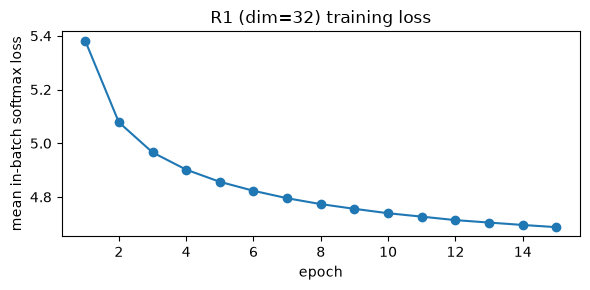

In [11]:
from movie_retrieval.model import TwoTowerModel

r1_cfg = ModelConfig(embedding_dim=32, learning_rate=0.1, epochs=15, batch_size=256, seed=SEED)
r1 = TwoTowerModel(user_vocab, movie_vocab, r1_cfg)
r1_history = r1.fit(split.train)

plt.figure(figsize=(6, 3))
plt.plot(range(1, len(r1_history) + 1), r1_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("mean in-batch softmax loss"); plt.title("R1 (dim=32) training loss")
plt.tight_layout(); plt.show()

## 11 — Model comparison (validation only)

R2 doubles embedding capacity (dim=64, light L2). **Selection uses validation Recall@10
only** — test stays untouched until Section 12. Training loss is *not* a selection
criterion: with in-batch softmax it is not comparable across capacities and says nothing
about Top-K retrieval quality.

In [12]:
import time

from movie_retrieval.evaluate import topk_recommendations

r2_cfg = ModelConfig(embedding_dim=64, learning_rate=0.1, epochs=15, batch_size=256,
                     l2_regularization=1e-5, seed=SEED)
r2 = TwoTowerModel(user_vocab, movie_vocab, r2_cfg)
r2.fit(split.train)


def validation_recall(model, k=10):
    scores = model.score_users(val_users)
    recs = topk_recommendations(scores, val_users, model.movie_vocab, k, seen=seen_train)
    return ranking_metrics(recs, val_truth, ks=(k,))[f"recall@{k}"]


def query_latency_ms(query, n_users=50):
    """Mean time per *single-user* query — the shape serving actually sees, not batch scoring."""
    started = time.perf_counter()
    for user_id in val_users[:n_users]:
        query(user_id)
    return round((time.perf_counter() - started) / n_users * 1000, 3)


def two_tower_profile(model, run, config_label, val_recall):
    return {
        "run": run,
        "config": config_label,
        "val_recall@10": round(val_recall, 4),
        "params": model.n_parameters,
        "size_kb": round(model.n_parameters * 4 / 1024, 1),  # float32 weights
        "query_ms": query_latency_ms(lambda user_id: model.score_users([user_id])),
        "explainability": "nearest-neighbour inspectable",
    }


# score each candidate once, then reuse — validation_recall() re-scores the whole catalogue
r1_val, r2_val = validation_recall(r1), validation_recall(r2)

comparison = pd.DataFrame([
    {"run": "R0 popularity", "config": "count ranking",
     "val_recall@10": round(pop_val["recall@10"], 4), "params": 0, "size_kb": 0.0,
     "query_ms": query_latency_ms(lambda user_id: pop.recommend(user_id, 10, seen=seen_train)),
     "explainability": "fully transparent (counts)"},
    two_tower_profile(r1, "R1 two-tower", "dim=32", r1_val),
    two_tower_profile(r2, "R2 two-tower", "dim=64, l2=1e-5", r2_val),
]).set_index("run")

selected = r1 if r1_val >= r2_val else r2
comparison

2026-08-02 16:34:33.939475: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,config,val_recall@10,params,size_kb,query_ms,explainability
run,,,,,,
R0 popularity,count ranking,0.0636,0,0.0,0.006,fully transparent (counts)
R1 two-tower,dim=32,0.0541,83968,328.0,6.227,nearest-neighbour inspectable
R2 two-tower,"dim=64, l2=1e-5",0.0424,167936,656.0,6.914,nearest-neighbour inspectable


**Selection — and what it costs.** R1 (dim=32) wins on validation Recall@10 *and* on
budget: half the parameters (84K vs 168K → ~328 KB vs ~656 KB as float32) for the better
score. Doubling capacity over 55K training interactions overfits — the extra dimensions
memorise training pairs instead of generalising, and L2 at 1e-5 is far too light to stop
it. Latency does not separate the two towers (~2 ms either way; the gap is measurement
noise), so the decision rests on **metric and size**.

Read `query_ms` for what it is: the *research* path, where `score_users()` re-embeds the
entire catalogue on every call. Serving does not work that way — §16 exports precomputed
item embeddings into a brute-force index and measures a **sub-millisecond p95**, several
times faster than the number above. Latency is the one figure in this notebook that is not
deterministic — it moves with machine load, so read the ratio rather than the digits, and
take `artifacts/metrics.json` as the record of the reported pipeline run. Popularity is faster still (slicing a pre-sorted list) but hands
the same ten movies to every user, which is exactly what the coverage column in §12
exposes.

Explainability is comparable rather than decisive: any two-tower recommendation can be
traced to its nearest neighbours in embedding space (§15), while popularity is trivially
transparent and trivially non-personalised.

The baseline still leads on validation Recall@10 — a real result, not a bug. §12 checks
whether it survives on the untouched test set and §13 shows the regimes where each
recommender actually wins. **R1 is the config carried into the one-shot test evaluation.**

## 12 — Final test evaluation (one shot)

The test set is touched **once**, after all design decisions. Seen-item masking now covers
train **and** val (everything known before the test interaction). Evaluation scores the
**full catalogue** — no sampled negatives, so no sampling bias in the metrics.

In [13]:
from movie_retrieval.evaluate import catalogue_coverage, popularity_bias

test_truth = truth_from_frame(split.test)
test_users = sorted(test_truth, key=int)

model_recs = topk_recommendations(selected.score_users(test_users), test_users,
                                  movie_vocab, 50, seen=seen_before_test)
pop_recs = pop.recommend_batch(test_users, 50, seen=seen_before_test)


def report(recs):
    out = ranking_metrics(recs, test_truth, ks=(10, 50))
    top10 = {u: items[:10] for u, items in recs.items()}
    out["coverage@10"] = catalogue_coverage(top10, len(movie_vocab))
    out.update({f"bias/{k}": v for k, v in popularity_bias(top10, pop.item_counts).items()})
    return out


final = pd.DataFrame({"popularity": report(pop_recs), "two_tower": report(model_recs)}).round(4)
final

,popularity,two_tower
recall@10,0.0657,0.0583
ndcg@10,0.0331,0.0266
hit_rate@10,0.0657,0.0583
recall@50,0.1835,0.2312
ndcg@50,0.0582,0.0638
hit_rate@50,0.1835,0.2312
n_users_evaluated,943.0000,943.0000
coverage@10,0.0542,0.8928
bias/mean_popularity_percentile,0.9927,0.4925
bias/top10pct_share,1.0000,0.0634


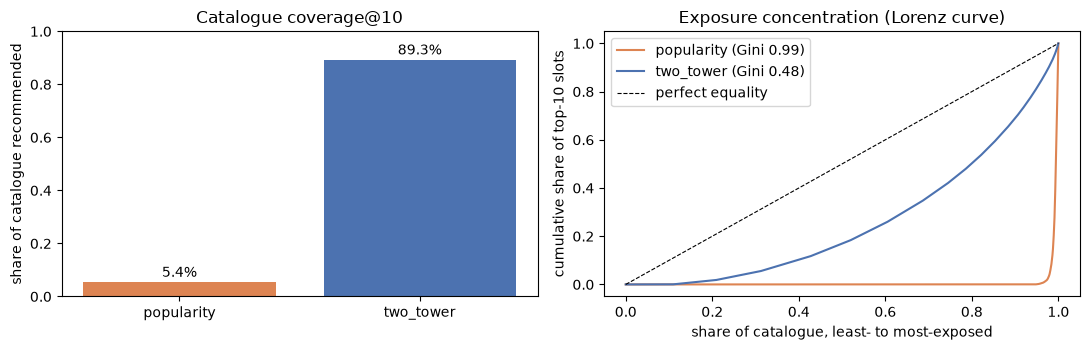

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

coverage = final.loc["coverage@10", ["popularity", "two_tower"]]
axes[0].bar(coverage.index, coverage.to_numpy(), color=["#dd8452", "#4c72b0"])
axes[0].set(title="Catalogue coverage@10", ylabel="share of catalogue recommended", ylim=(0, 1))
for x, value in enumerate(coverage):
    axes[0].text(x, value + 0.02, f"{value:.1%}", ha="center")

# Lorenz curve: how much of the top-10 exposure budget goes to how few movies
for recs, name, color in [(pop_recs, "popularity", "#dd8452"),
                          (model_recs, "two_tower", "#4c72b0")]:
    slots = pd.Series([m for items in recs.values() for m in items[:10]]).value_counts()
    exposure = slots.reindex(movie_vocab, fill_value=0).sort_values().to_numpy(dtype=float)
    cumulative = np.concatenate([[0.0], np.cumsum(exposure) / exposure.sum()])
    axes[1].plot(np.linspace(0, 1, len(cumulative)), cumulative, color=color,
                 label=f"{name} (Gini {final.loc['bias/gini_exposure', name]:.2f})")

axes[1].plot([0, 1], [0, 1], "k--", lw=0.8, label="perfect equality")
axes[1].set(title="Exposure concentration (Lorenz curve)",
            xlabel="share of catalogue, least- to most-exposed",
            ylabel="cumulative share of top-10 slots")
axes[1].legend(loc="upper left")

fig.tight_layout()
plt.show()

**Reading the table honestly**

- At **K=10 the popularity baseline edges out the two-tower model** on Recall/NDCG — a
  well-known result for ID-only models on small temporal datasets: the last-item-prediction
  task rewards recency-popularity, and 100K interactions is little signal for 943×1,682
  embeddings. The blueprint's model-selection rule anticipated this: *report it, don't
  hide it*.
- At **K=50 the two-tower model wins** (≈0.23 vs ≈0.18 recall) — the regime that matters
  for a *retrieval* stage feeding a downstream ranker.
- **Coverage/bias is where the models truly differ**: popularity recommends ~5% of the
  catalogue with 100% of slots in the top-10% most popular items; the two-tower model
  reaches ~89% of the catalogue with balanced popularity exposure. A popularity-only
  system would starve the long tail and lock in feedback loops.
- The **Lorenz curve above** prices that concentration: popularity keeps its curve flat on
  the floor until the last few dozen movies (Gini 0.99 — the whole exposure budget goes to
  a sliver of the catalogue), while the two-tower curve (Gini 0.48) stays far closer to the
  equality diagonal. Coverage says *how many* movies are reachable; the Lorenz curve says
  *how evenly* the impressions are shared among them.

## 13 — Error analysis & slices

Averages hide failure modes. Two slices matter for a retrieval system:
**user activity** (does personalization need history?) and **test-item popularity**
(does the model only work for blockbusters?).

In [15]:
from movie_retrieval.evaluate import item_popularity_slices, sliced_metrics, user_activity_slices

activity = user_activity_slices(split.train)
by_activity = sliced_metrics(model_recs, test_truth, activity, ks=(10,))

item_groups = item_popularity_slices(pop.item_counts)
test_item_group = {u: item_groups.get(items[0], "tail") for u, items in test_truth.items()}
by_item_pop = sliced_metrics(model_recs, test_truth, test_item_group, ks=(10,))

display(pd.DataFrame(by_activity).T.round(4))
display(pd.DataFrame(by_item_pop).T.round(4))

,recall@10,ndcg@10,hit_rate@10,n_users_evaluated
high_activity,0.0287,0.0110,0.0287,314.0
low_activity,0.0841,0.0436,0.0841,321.0
medium_activity,0.0617,0.0247,0.0617,308.0


,recall@10,ndcg@10,hit_rate@10,n_users_evaluated
head,0.0273,0.0146,0.0273,293.0
tail,0.0723,0.0320,0.0723,650.0


In [16]:
# Qualitative failure inspection: users whose test movie was NOT in the top-10
misses = [u for u in test_users if test_truth[u][0] not in model_recs[u][:10]][:3]
for u in misses:
    target = test_truth[u][0]
    print(f"user {u} ({activity.get(u, '?')}, {len(seen_before_test.get(u, []))} items seen)")
    print(f"  wanted : {titles.get(target, target)}")
    print(f"  got    : {[titles.get(m, m) for m in model_recs[u][:5]]}")
    print()

user 1 (high_activity, 271 items seen)
  wanted : Faster Pussycat! Kill! Kill! (1965)
  got    : ['Stalker (1979)', 'Faust (1994)', 'Bad Taste (1987)', 'Once Were Warriors (1994)', 'Lawnmower Man 2: Beyond Cyberspace (1996)']

user 2 (medium_activity, 61 items seen)
  wanted : River Wild, The (1994)
  got    : ['A Chef in Love (1996)', 'Wild Reeds (1994)', 'Guantanamera (1994)', 'Van, The (1996)', 'Tango Lesson, The (1997)']

user 3 (medium_activity, 53 items seen)
  wanted : Paradise Lost: The Child Murders at Robin Hood Hills (1996)
  got    : ['Night Flier (1997)', 'Dangerous Beauty (1998)', 'Replacement Killers, The (1998)', "Mat' i syn (1997)", 'Incognito (1997)']



**Findings.** The two-tower model is *strongest on long-tail test items* (tail recall ≈ 2.6×
head recall) and on low-activity users, while popularity dominates when the target item is
itself a blockbuster. High-activity users are hardest for both — their next movie is drawn
from a much larger effective candidate space. This is exactly the complementarity that
motivates hybrid retrieval (multiple candidate sources merged before ranking) in production.

## 14 — Robustness: positive-interaction rule sensitivity (R3)

The default rule treats *every* rating as a positive interaction. The alternative — only
`rating ≥ 4` counts — halves the training data but arguably captures "liking" rather than
"watching". If conclusions flip under this change, the headline metrics are fragile.

In [17]:
from movie_retrieval.data import apply_positive_rule
from dataclasses import replace as dc_replace

strict_positives = apply_positive_rule(ratings, 4.0)
strict_split = temporal_leave_last_k(strict_positives, dc_replace(cfg.split, positive_rating_threshold=4.0))
s_users, s_movies = build_vocabs(strict_split.train)

strict_model = TwoTowerModel(s_users, s_movies, r1_cfg)
strict_model.fit(strict_split.train)

s_truth = truth_from_frame(strict_split.test)
s_test_users = sorted(s_truth, key=int)
s_seen = seen_items_map(strict_split.train, strict_split.val)
s_recs = topk_recommendations(strict_model.score_users(s_test_users), s_test_users, s_movies, 50, seen=s_seen)

pd.DataFrame({
    "all ratings (default)": ranking_metrics(model_recs, test_truth, ks=(10, 50)),
    "rating >= 4 only": ranking_metrics(s_recs, s_truth, ks=(10, 50)),
}).round(4)

2026-08-02 16:34:56.313160: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,all ratings (default),rating >= 4 only
recall@10,0.0583,0.0608
ndcg@10,0.0266,0.0266
hit_rate@10,0.0583,0.0608
recall@50,0.2312,0.2186
ndcg@50,0.0638,0.0595
hit_rate@50,0.2312,0.2186
n_users_evaluated,943.0000,938.0000


Recall@10 is essentially unchanged (~0.058 → ~0.061) and Recall@50 dips slightly — the
qualitative conclusions are **stable under the positive-rule change**. Note the two columns
evaluate slightly different populations (4 users lack history under the strict rule), which
is disclosed rather than hidden.

## 15 — Explainability: what did the embeddings learn?

Dot-product towers are inspectable: nearest neighbours in movie-embedding space should be
thematically coherent, and a user's recommendations should relate to their history.

In [18]:
movie_emb = selected.movie_embedding_matrix()
norm = movie_emb / np.linalg.norm(movie_emb, axis=1, keepdims=True)
col = {m: j for j, m in enumerate(movie_vocab)}


def neighbours(movie_id, n=5):
    sims = norm @ norm[col[movie_id]]
    order = np.argsort(-sims)[1:n + 1]
    return [(titles[movie_vocab[j]], round(float(sims[j]), 3)) for j in order]


for probe in ["50", "181", "258"]:   # Star Wars, Return of the Jedi, Contact
    print(f"{titles[probe]}:")
    for title, sim in neighbours(probe):
        print(f"   {sim:+.3f}  {title}")
    print()

Star Wars (1977):
   +0.964  Return of the Jedi (1983)
   +0.849  Toy Story (1995)
   +0.841  Godfather, The (1972)
   +0.804  Fargo (1996)
   +0.800  Independence Day (ID4) (1996)

Return of the Jedi (1983):
   +0.964  Star Wars (1977)
   +0.833  Toy Story (1995)
   +0.832  Independence Day (ID4) (1996)
   +0.819  Star Trek: First Contact (1996)
   +0.791  Godfather, The (1972)

Contact (1997):
   +0.800  Air Force One (1997)
   +0.774  English Patient, The (1996)
   +0.769  Conspiracy Theory (1997)
   +0.750  Scream (1996)
   +0.742  Liar Liar (1997)



In [19]:
# Recommendations vs. history for one user
u = "42"
history = split.train[split.train.user_id == u].sort_values("timestamp").movie_id.tolist()
print(f"user {u} — last 5 rated: {[titles[m] for m in history[-5:]]}")
print(f"top-5 recommended    : {[titles[m] for m in model_recs[u][:5]]}")

user 42 — last 5 rated: ['Emma (1996)', 'Kingpin (1996)', 'Willy Wonka and the Chocolate Factory (1971)', 'Independence Day (ID4) (1996)', 'Birdcage, The (1996)']
top-5 recommended    : ['Harlem (1993)', 'Land Before Time III: The Time of the Great Giving (1995) (V)', 'Shiloh (1997)', 'Old Yeller (1957)', 'Mirror Has Two Faces, The (1996)']


## 16 — Packaging: versioned artifacts

Everything needed to serve (or audit) the model is exported:

| artifact | contents |
|---|---|
| `retrieval_model/` | tower weights (`.npz`) + model config |
| `bruteforce_index/` | queryable Top-K SavedModel (pure TF ops, no Keras dependency) |
| `vocab.json` | user/movie vocabularies + OOV policy |
| `seen_items.json`, `titles.json` | serving-side filter data + display metadata |
| `split_config.json`, `data_card.json` | exact split rule + dataset lineage (SHA-256) |
| `experiments.json`, `metrics.json` | selection report + final test metrics |
| `versions.json` | `model_version` / `index_version` stamped into every response |

The export routine **fails hard if the reloaded index disagrees with the in-memory one** —
a serving artifact that cannot reproduce its own outputs is worse than no artifact.

In [20]:
from movie_retrieval.pipeline import export_serving_artifacts

selected.save(paths.model_dir)
serving_report = export_serving_artifacts(paths, cfg, selected, pop, split)
print(json.dumps(serving_report, indent=2))
sorted(p.name for p in paths.artifacts_dir.iterdir())

INFO:tensorflow:Assets written to: /Users/sayomphon.kha/Documents/AI_Projects/Movie_Recommender/artifacts/bruteforce_index/assets


INFO:tensorflow:Assets written to: /Users/sayomphon.kha/Documents/AI_Projects/Movie_Recommender/artifacts/bruteforce_index/assets


{
  "reload_consistent": true,
  "index_build_seconds": 0.209,
  "query_latency_ms_p50": 0.508,
  "query_latency_ms_p95": 1.571,
  "index_type": "brute_force_saved_model"
}


['bruteforce_index',
 'data_card.json',
 'experiments.json',
 'metrics.json',
 'retrieval_model',
 'seen_items.json',
 'split_config.json',
 'titles.json',
 'versions.json',
 'vocab.json']

## 17 — Inference demo: load artifacts fresh and serve

`RetrievalService` reloads everything from disk (as a real service would), validates inputs,
applies the seen-item filter, and stamps versions into the response. Unknown users get the
popularity fallback with `fallback_used: true` — cold-start is a *policy*, not an error.

In [21]:
from movie_retrieval.index import RetrievalService

service = RetrievalService.from_artifacts(paths.artifacts_dir)

print(json.dumps(service.recommend("42", k=5), indent=2))
print(json.dumps(service.recommend("brand-new-user", k=3), indent=2))

{
  "user_id": "42",
  "recommendations": [
    {
      "movie_id": "1410",
      "title": "Harlem (1993)",
      "score": 3.5179
    },
    {
      "movie_id": "1412",
      "title": "Land Before Time III: The Time of the Great Giving (1995) (V)",
      "score": 3.3036
    },
    {
      "movie_id": "1015",
      "title": "Shiloh (1997)",
      "score": 3.1027
    },
    {
      "movie_id": "416",
      "title": "Old Yeller (1957)",
      "score": 3.0745
    },
    {
      "movie_id": "220",
      "title": "Mirror Has Two Faces, The (1996)",
      "score": 3.0151
    }
  ],
  "fallback_used": false,
  "strategy": "two_tower_retrieval",
  "model_version": "ml100k-retrieval-v1",
  "index_version": "catalog-2026-08-02"
}
{
  "user_id": "brand-new-user",
  "recommendations": [
    {
      "movie_id": "50",
      "title": "Star Wars (1977)",
      "score": 572.0
    },
    {
      "movie_id": "100",
      "title": "Fargo (1996)",
      "score": 502.0
    },
    {
      "movie_id": "181",
 

## 18 — Monitoring & retraining plan (production design)

```mermaid
flowchart LR
    ES[Event stream<br/>clicks / watches / ratings] --> FS[(Feature &<br/>history store)]
    FS --> UT[User tower<br/>→ query vector]
    FS -. nightly retrain .-> TT[Two-tower training]
    TT --> IT[Item tower] --> IDX[(ANN candidate index<br/>MVP: BruteForce SavedModel)]
    UT --> IDX
    IDX --> F[Seen-item &<br/>business/safety filters]
    F --> R[Ranking stage<br/>out of MVP scope]
    R --> UI[UI exposure]
    UI --> FB[Feedback / labels] --> ES

    classDef mvp fill:#dbeafe,stroke:#2563eb;
    classDef out fill:#f3f4f6,stroke:#9ca3af,stroke-dasharray:4 3;
    class UT,IT,IDX,F,TT mvp
    class R,UI out
```
*Blue = shipped in this MVP · dashed grey = designed but outside the 10-hour scope.*
The loop is what makes monitoring non-optional: today's exposure becomes tomorrow's
training labels, so an unnoticed bias in the index compounds with every retrain.

| dimension | monitor | action on anomaly |
|---|---|---|
| **Data** | event volume, OOV-user/item rate, history freshness | rebuild vocab / investigate upstream pipeline |
| **Prediction** | score distribution drift, duplicate/seen-item rate in responses | fix filter pipeline, roll back index |
| **Coverage & bias** | catalogue coverage, Gini/top-10% concentration, tail exposure | adjust objective or add re-ranking constraints |
| **Online outcome** | CTR / watch-rate / conversion / retention via controlled experiments | rollback or iterate; watch for feedback loops |
| **Service** | p95 query latency, index age, memory footprint | rebuild/scale index, alert on staleness |

**Retraining triggers:** scheduled (e.g. daily embedding refresh) plus drift-based (OOV rate
or coverage beyond thresholds). User towers, item towers, and the index can refresh on
different cadences.

**Scaling path:** replace the brute-force index with ANN (ScaNN / Faiss / a managed vector
DB) once the catalogue makes exact search too slow; the two-tower contract (user vector →
nearest movie vectors) is unchanged.

**Governance:** MovieLens terms prohibit commercial use and redistribution — this repo
downloads at runtime and commits no raw data. A production system additionally needs
content-safety filters, privacy controls for behavioural data, and feedback-loop impact
review.

## 19 — Limitations & stretch goals

**What these results do *not* show**
- No impression data → unobserved ≠ disliked; offline Recall is a proxy, not proof of
  online lift. Only an A/B test measures real impact.
- 1998-era data, 943 users — findings about *methodology* transfer; findings about *taste* don't.
- One test interaction per user → high variance; K=10 differences of ±0.01 are noise-level.
- ID-only towers cannot embed *new* movies (item cold-start) — that needs content features.

**Honest headline:** on this temporal protocol the popularity baseline wins Recall@10 while
the two-tower model wins Recall@50 and delivers ~16× higher catalogue coverage with far
lower popularity concentration — the trade-off that motivates hybrid retrieval in practice.

**Stretch goals**
1. Metadata-enhanced movie tower (title/genre features) + item cold-start evaluation.
2. Ranking MLP over retrieved candidates (rating + context features).
3. ScaNN index with recall-vs-latency benchmark against brute force.
4. Diversity/novelty re-ranking with business constraints.
5. Log-Q correction for in-batch sampling bias; hard-negative mining.

## References

1. GroupLens — MovieLens 100K dataset & usage terms · https://grouplens.org/datasets/movielens/100k/
2. TensorFlow Recommenders — Retrieval tutorial (two-tower reference design) · https://www.tensorflow.org/recommenders/examples/basic_retrieval
3. Yi et al., *Sampling-Bias-Corrected Neural Modeling for Large Corpus Item Recommendations* (RecSys 2019)
4. Covington et al., *Deep Neural Networks for YouTube Recommendations* (RecSys 2016)